<a href="https://colab.research.google.com/github/m-tauqueer/2029-Group-C-WebDev/blob/main/Math's_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

!pip install seaborn
import seaborn as sns

url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749"
df = pd.read_csv(url)

df.head()

,Product,Age,Gender,Education,MaritalStatus,Usage,Fitness,Income,Miles
0,KP281,18,Male,14,Single,3,4,29562,112
1,KP281,19,Male,15,Single,2,3,31836,75
2,KP281,19,Female,14,Partnered,4,3,30699,66
3,KP281,19,Male,12,Single,3,3,32973,85
4,KP281,20,Male,13,Partnered,4,2,35247,47


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 180 entries, 0 to 179
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Product        180 non-null    object
 1   Age            180 non-null    int64 
 2   Gender         180 non-null    object
 3   Education      180 non-null    int64 
 4   MaritalStatus  180 non-null    object
 5   Usage          180 non-null    int64 
 6   Fitness        180 non-null    int64 
 7   Income         180 non-null    int64 
 8   Miles          180 non-null    int64 
dtypes: int64(6), object(3)
memory usage: 12.8+ KB


As we can see there are no missing values but stills duplicates and outliers can still exist

In [ ]:
df.describe()

,Age,Education,Usage,Fitness,Income,Miles
count,180.000000,180.000000,180.000000,180.000000,180.000000,180.000000
mean,28.788889,15.572222,3.455556,3.311111,53719.577778,103.194444
std,6.943498,1.617055,1.084797,0.958869,16506.684226,51.863605
min,18.000000,12.000000,2.000000,1.000000,29562.000000,21.000000
25%,24.000000,14.000000,3.000000,3.000000,44058.750000,66.000000
50%,26.000000,16.000000,3.000000,3.000000,50596.500000,94.000000
75%,33.000000,16.000000,4.000000,4.000000,58668.000000,114.750000
max,50.000000,21.000000,7.000000,5.000000,104581.000000,360.000000


**Bussiness level thoughts**


1. Target users = young, educated, mid-income individuals
2. Average treadmill usage is moderate (3–4 times/week)
3. Product likely used for regular fitness, not hardcore training
4. Some premium/high-usage segment exists (outliers)








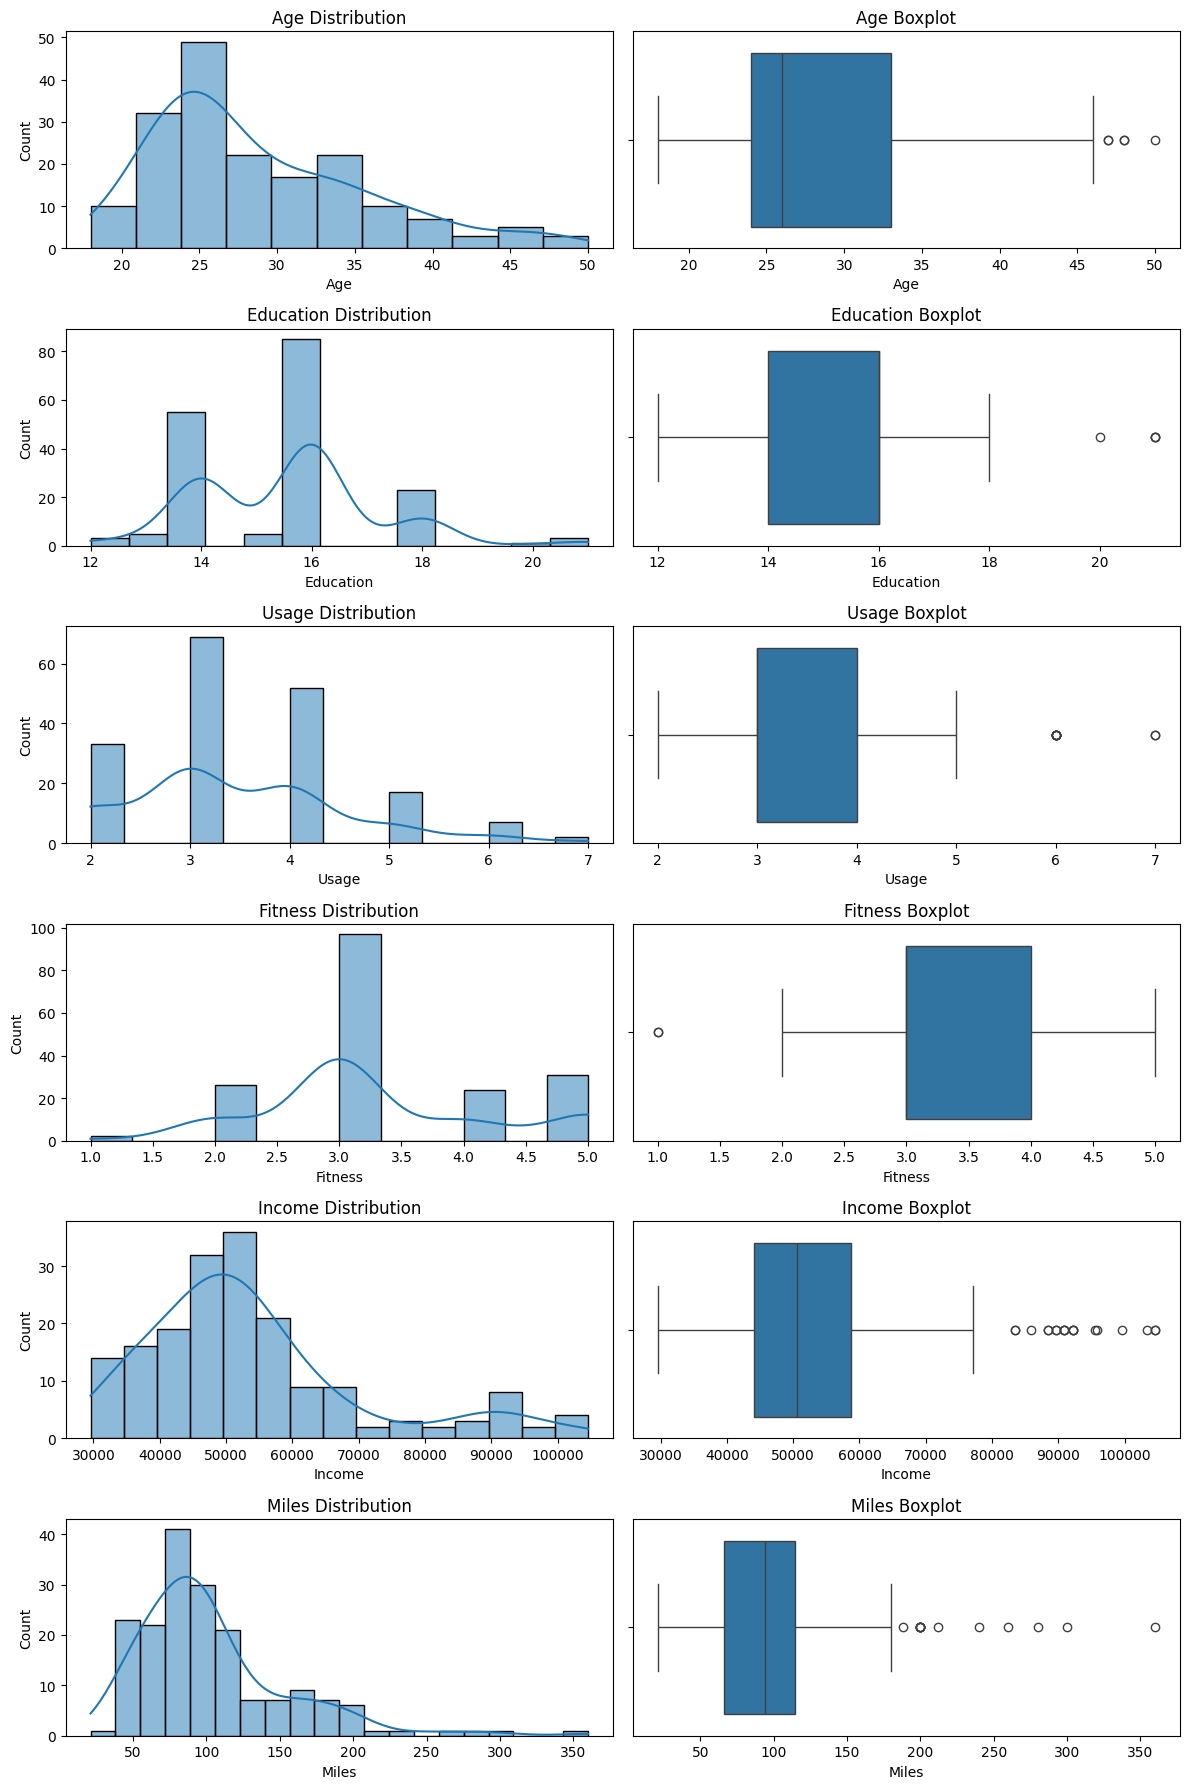

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
url = "https://d2beiqkhq929f0.cloudfront.net/public_assets/assets/000/001/125/original/aerofit_treadmill.csv?1639992749"
df = pd.read_csv(url)
cols = df.select_dtypes(include=['number']).columns
fig, axes = plt.subplots(len(cols), 2, figsize=(12, 18))

for i, col in enumerate(cols):

    sns.histplot(df[col], kde=True, ax=axes[i, 0])
    axes[i, 0].set_title(f'{col} Distribution')


    sns.boxplot(x=df[col], ax=axes[i, 1])
    axes[i, 1].set_title(f'{col} Boxplot')

plt.tight_layout()
plt.show()

**Univariate Analysis**

•Age – The histogram is slightly right-skewed, suggesting the presence of a
     smaller number of older individuals. The boxplot shows a median age of 26, with the majority of users falling between 24 and 33 years, and no noticeable outliers. This indicates that the product is predominantly used by a younger demographic.


•Education – The histogram reflects a balanced distribution, and the boxplot     confirms the absence of outliers. This suggests that most users in the dataset have a relatively high level of education.


•Usage – The histogram indicates that users typically engage with the product around 3 to 4 times per week. There are no significant outliers, implying consistent and moderate usage patterns rather than excessive use.


•Income – The distribution is right-skewed, with a longer tail toward higher income levels. The boxplot highlights a few high-income outliers, while the majority of users fall within the mid-income range. This suggests that the primary user base belongs to the middle and upper-middle income groups.


•Miles – The histogram shows a pronounced right skew, indicating that most users cover moderate distances, while a small number travel significantly higher distances. The boxplot identifies extreme values in the upper range. Overall, most users maintain moderate activity levels, with a minority being highly active.






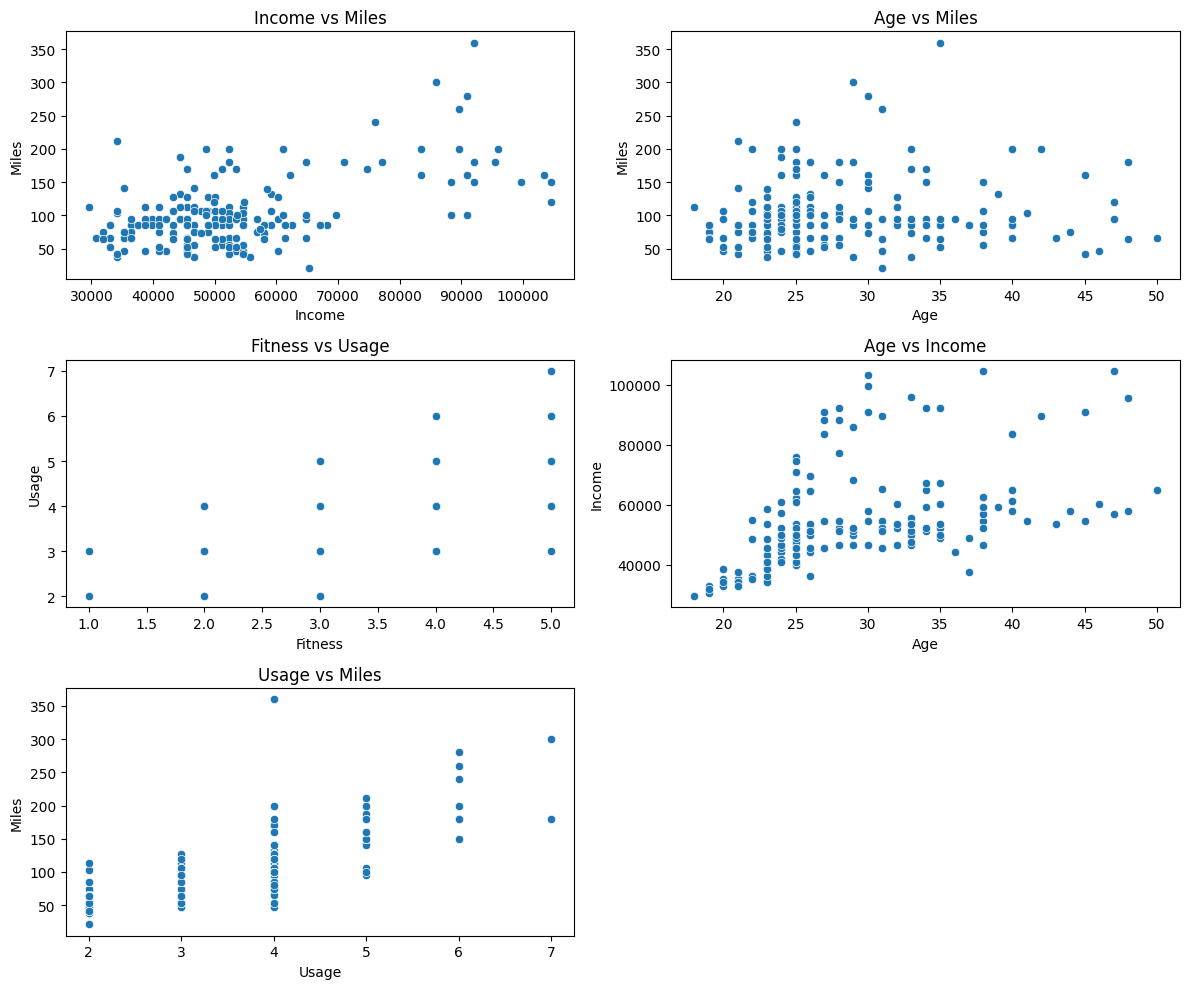

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt


pairs = [
    ('Income', 'Miles'),
    ('Age', 'Miles'),
    ('Fitness', 'Usage'),
    ('Age', 'Income'),
    ('Usage', 'Miles')
]

plt.figure(figsize=(12, 10))

for i, (x, y) in enumerate(pairs):
    plt.subplot(3, 2, i+1)
    sns.scatterplot(x=df[x], y=df[y])
    plt.title(f"{x} vs {y}")

plt.tight_layout()
plt.show()

**Income vs Miles**:
The scatter plot indicates a weak positive association between income and miles covered. The data points are widely spread, suggesting a low level of correlation. Although there is a slight linear trend, variability is high. A few outliers with high mileage appear in the higher income range. Overall, income does not significantly influence fitness levels, and other factors are likely more important.


**Fitness vs Usage**:
A strong positive relationship is evident between fitness level and product usage. The points form a clear upward trend with relatively low dispersion, indicating a high correlation. The relationship appears linear with minimal outliers. This suggests that individuals with higher fitness levels tend to use the treadmill more frequently than those with lower fitness levels.


**Age vs Miles**:
The scatter plot shows little to no meaningful relationship between age and miles covered. The points are randomly distributed without any clear pattern or trend. Despite age often being linked to fitness in real life, this dataset does not show any significant impact of age on distance covered.


**Usage vs Miles**:
A moderate positive relationship exists between usage frequency and miles covered. As usage increases, the number of miles tends to rise as well. The trend is somewhat linear, though there is some variability in the data. A few higher-mile observations act as mild outliers. This aligns with expectations, as more frequent usage generally leads to greater distance covered.


**Age vs Income**:
The scatter plot reveals a moderate positive relationship between age and income. As individuals grow older, their income tends to increase. The pattern is fairly linear with a moderate spread of points, indicating a consistent upward trend.

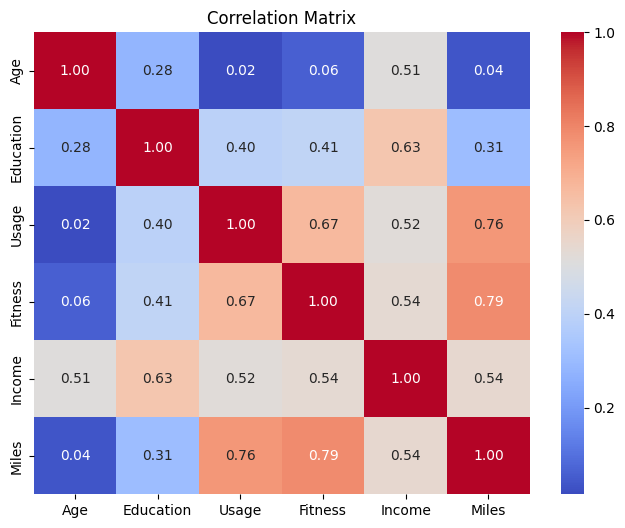

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

corr = df.select_dtypes(include=['number']).corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix")

plt.show()

**Correlation Analysis**

**Strong Relationships**

   •**Fitness vs Miles (0.79)**
   This indicates a very strong positive correlation. As fitness levels increase, the distance covered also increases significantly.

   •**Usage vs Miles (0.76)**
   A strong positive relationship is observed here. Greater usage of the machine is associated with higher miles covered.

   •**Usage vs Fitness (0.67)**
This shows a strong correlation as well. Increased usage of the treadmill is linked to better fitness levels.



**Moderate Relationships**

   •**Income vs Education (0.63)**
There is a moderate positive correlation, suggesting that higher education often leads to higher income. However, this is not always consistent, as real-world exceptions exist.

   •**Income vs Usage (0.54)**
A moderate relationship is observed between income and treadmill usage. While higher income may be associated with increased usage, the presence of outliers affects the overall trend. Additionally, fitness levels are not strictly dependent on income, as both low- and high-income individuals can be equally fit.

   **Weak Relationship**
   
•**Age**
Age shows weak correlations with other variables in this dataset. Although age often influences fitness in real-life scenarios, no strong relationship is evident here.

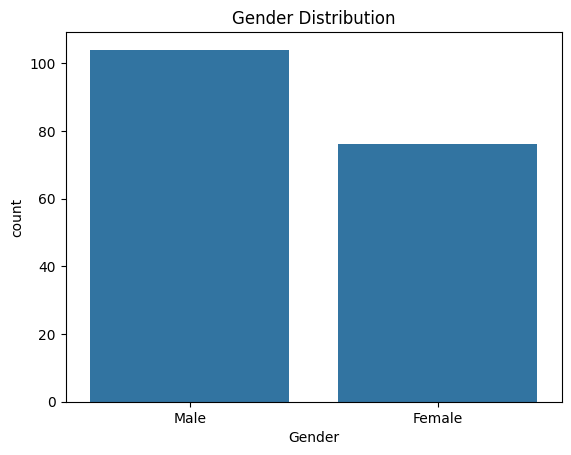

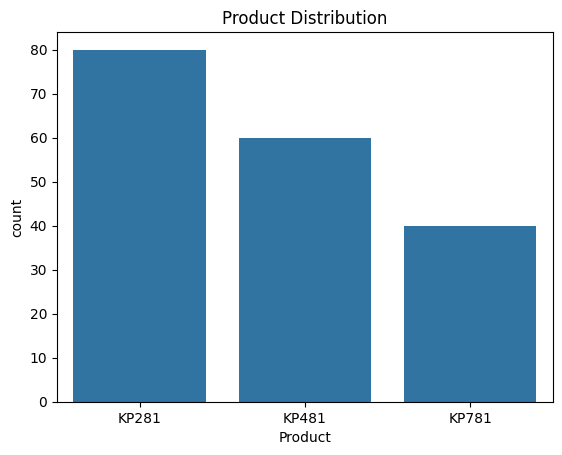

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

cat_cols = ['Gender', 'Product']

for col in cat_cols:
    sns.countplot(x=df[col])
    plt.title(f"{col} Distribution")
    plt.show()

**Gender vs Income:**

Males tend to have slightly higher income distribution compared to females.



---



**Product vs Miles:**

Users of KP481 show higher median miles, indicating more active users.

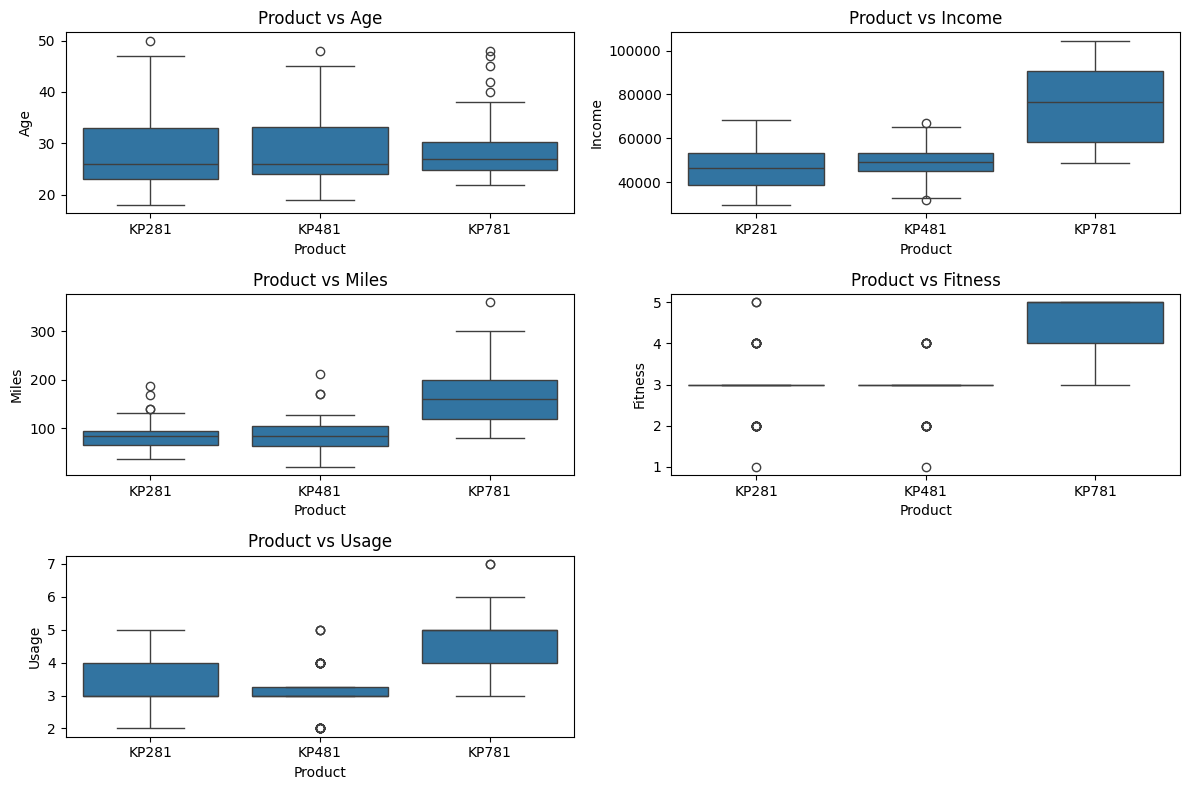

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

cat_col = 'Product'
num_cols = ['Age', 'Income', 'Miles', 'Fitness', 'Usage']

plt.figure(figsize=(12, 8))

for i, col in enumerate(num_cols):
    plt.subplot(3, 2, i+1)
    sns.boxplot(x=df[cat_col], y=df[col])
    plt.title(f"{cat_col} vs {col}")

plt.tight_layout()
plt.show()

**Summary**:

The boxplot comparison across different products highlights distinct variations in user behavior. Premium products like KP781 are linked with higher income levels, greater usage frequency, and more miles covered, suggesting they attract more active and financially well-off users. On the other hand, entry-level products such as KP281 are generally used by less active individuals. The age distribution appears similar across all products, indicating that user preference is driven more by fitness level and income rather than age.


---



**Key Insights**:

•Fitness and usage exhibit a strong positive relationship

•Increased usage leads to higher miles covered

•Income has a limited impact on overall activity levels

•Age does not significantly influence usage or distance covered

•The majority of users are young, well-educated, and moderately active

•A small group of high-mile users represents a highly active niche segment


---



**Business Insights on Products**:

**Clear Product Segmentation**

Each product serves a distinct user category:

•KP281 (Entry-level) → beginners or low-activity users

•KP481 (Mid-range) → moderately active users

•KP781 (Premium) → highly active or performance-focused users


**Premium Products Attract Higher-Income Users**


Users of KP781 tend to have higher median incomes, while KP281 has a larger customer base due to its affordability.

**Higher Product Tier Drives Engagement**

Users of KP781:

•Use the treadmill more frequently.

•Cover greater distances.

This indicates that advanced products are favored by users with higher engagement levels.


---



**Future Scope**

Sales growth can be achieved by leveraging customer segmentation, behavioral data, and personalized strategies. Targeting users based on their fitness levels and usage habits, promoting product upgrades at the right time, and focusing on high-value customers with premium offerings can boost conversions and revenue. Additionally, strategies such as user engagement initiatives, product bundling, and data-driven decision-making can improve customer retention and maximize lifetime value.